#  The Half-Life of Hype
## How long does a luxury brand's cultural moment actually last and what does the data say happens next?

---

Fashion, apparently, is not just about what you wear. It is about 
what you choose — and more importantly, when. The cerulean blue 
in your wardrobe did not arrive there by accident. It started 
somewhere. It moved through culture, through editorials, through 
celebrity dressing and street style and the quiet consensus of 
people who decide these things, until it landed in a discount bin 
and everyone stopped caring. That journey has a shape. And that 
Shape has a half-life.

This project is not written by someone who can identify a Birkin 
from across the room. It is written by someone who can tell you. 
exactly when the internet decided Loewe was the most important 
brand on earth down to the month and how long that moment 
lasted before the next one arrived. Fashion moves fast. Data 
keeps up.

Six brands. Five years. One question: when the hype arrives, 
how long before it starts to fade and which brands have figured 
out how to make it last?

---

**Brands:** Miu Miu · Balenciaga · Louis Vuitton · Dior · Valentino · Loewe
**Data:** Google Trends interest index — Worldwide, 2020–2024
**Tools:** Python · pandas · Plotly · NumPy · scipy
**Analyst:** Trupthi Raj

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
os.makedirs('charts', exist_ok=True)

# === LOAD ALL SIX BRANDS ===
brands = {
    'Miu Miu'      : 'data/miu_miu.csv',
    'Balenciaga'   : 'data/balenciaga.csv',
    'Louis Vuitton': 'data/louis_vuitton.csv',
    'Dior'         : 'data/dior.csv',
    'Valentino'    : 'data/valentino.csv',
    'Loewe'        : 'data/loewe.csv'
}

brand_colors = {
    'Miu Miu'      : '#D4537E',
    'Balenciaga'   : '#534AB7',
    'Louis Vuitton': '#BA7517',
    'Dior'         : '#1D9E75',
    'Valentino'    : '#FF6B6B',
    'Loewe'        : '#2196F3'
}

dfs = []
for brand, path in brands.items():
    df = pd.read_csv(path, skiprows=1)
    df.columns = ['Month', 'Interest']
    df['Brand'] = brand
    df['Month'] = pd.to_datetime(df['Month'])
    df['Interest'] = pd.to_numeric(df['Interest'], errors='coerce')
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.dropna(subset=['Interest'])
df_all = df_all[df_all['Month'] >= '2020-01-01'].copy()
df_all = df_all.sort_values(['Brand', 'Month']).reset_index(drop=True)

print(f"Total rows: {len(df_all):,}")
print(f"\nBrands loaded: {df_all['Brand'].unique().tolist()}")
print(f"\nDate range: {df_all['Month'].min()} → {df_all['Month'].max()}")
print(f"\nRows per brand:")
print(df_all.groupby('Brand')['Interest'].count())
print(f"\nInterest range per brand:")
print(df_all.groupby('Brand')['Interest'].agg(['min', 'max', 'mean']).round(1))

Total rows: 360

Brands loaded: ['Balenciaga', 'Dior', 'Loewe', 'Louis Vuitton', 'Miu Miu', 'Valentino']

Date range: 2020-01-01 00:00:00 → 2024-12-01 00:00:00

Rows per brand:
Brand
Balenciaga       60
Dior             60
Loewe            60
Louis Vuitton    60
Miu Miu          60
Valentino        60
Name: Interest, dtype: int64

Interest range per brand:
               min  max  mean
Brand                        
Balenciaga       1  100  29.5
Dior             0  100  41.6
Loewe            0  100  42.6
Louis Vuitton    0  100  40.9
Miu Miu         20  100  44.3
Valentino        0  100  37.8


## Act 1: The Hype Map

Google Trends measures search interest on a scale of 0 to 100. 
100 is peak popularity, the moment a brand is searched more than 
it has ever been searched in the selected period. Everything else 
is relative to that peak. It is not absolute volume. It is 
cultural temperature.

Five years of cultural temperature for six luxury brands is about 
to tell you more than five years of press releases ever could. 
The spikes are the moments, a controversy, a collaboration, a 
celebrity, a single viral image that changed everything. The 
valleys are what happens after. And the distance between the two 
is the story this project exists to tell.

The chart below is the opening shot. Six brands. Sixty months. 
Every spike has a reason. The annotations tell you what it was.

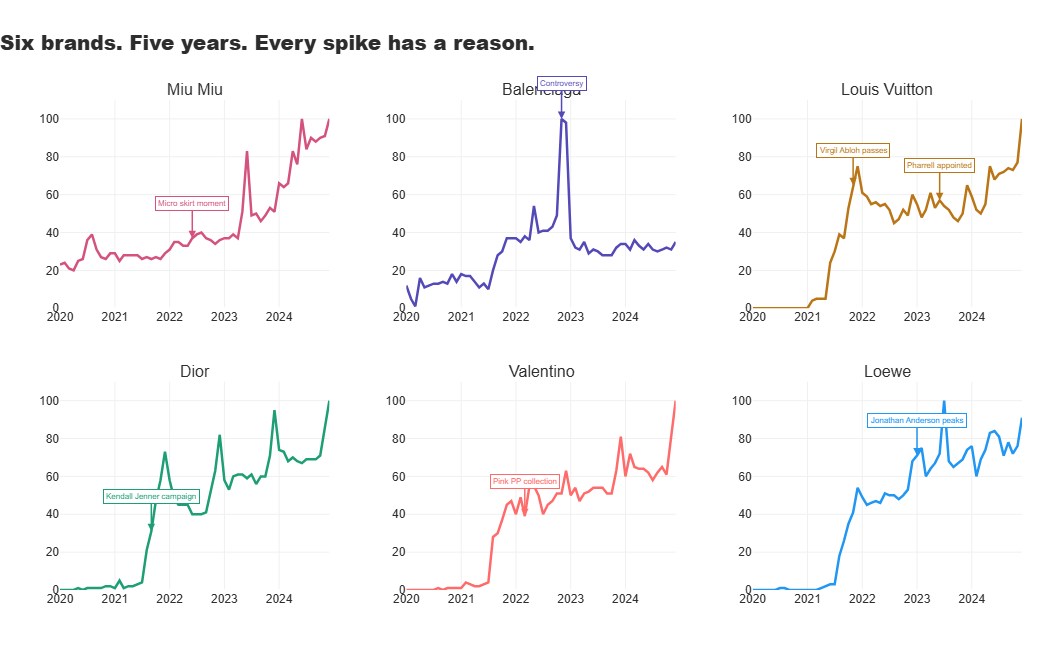

Chart 1 saved.


In [13]:
# === CHART 1: THE HYPE MAP — SMALL MULTIPLES ===

events_dict = {
    'Balenciaga'   : [{'date': '2022-11-01', 'label': 'Controversy'}],
    'Miu Miu'      : [{'date': '2022-06-01', 'label': 'Micro skirt moment'}],
    'Louis Vuitton': [{'date': '2021-11-01', 'label': 'Virgil Abloh passes'},
                      {'date': '2023-06-01', 'label': 'Pharrell appointed'}],
    'Valentino'    : [{'date': '2022-03-01', 'label': 'Pink PP collection'}],
    'Loewe'        : [{'date': '2023-01-01', 'label': 'Jonathan Anderson peaks'}],
    'Dior'         : [{'date': '2021-09-01', 'label': 'Kendall Jenner campaign'}],
}

brand_list = ['Miu Miu', 'Balenciaga', 'Louis Vuitton', 
              'Dior', 'Valentino', 'Loewe']

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=brand_list,
    horizontal_spacing=0.08,
    vertical_spacing=0.15
)

positions = {
    'Miu Miu'      : (1, 1),
    'Balenciaga'   : (1, 2),
    'Louis Vuitton': (1, 3),
    'Dior'         : (2, 1),
    'Valentino'    : (2, 2),
    'Loewe'        : (2, 3)
}

for brand in brand_list:
    row, col = positions[brand]
    color = brand_colors[brand]
    brand_data = df_all[df_all['Brand'] == brand].copy()

    fig.add_trace(go.Scatter(
        x=brand_data['Month'],
        y=brand_data['Interest'],
        mode='lines',
        name=brand,
        line=dict(color=color, width=2.5),
        showlegend=False,
        hovertemplate=(
            f"<b>{brand}</b><br>"
            "Month: %{x|%B %Y}<br>"
            "Interest: %{y}<extra></extra>"
        )
    ), row=row, col=col)

    if brand in events_dict:
        for event in events_dict[brand]:
            event_date = pd.to_datetime(event['date'])
            match = brand_data[brand_data['Month'] == event_date]
            if len(match) == 0:
                continue
            y_val = match['Interest'].values[0]

            fig.add_annotation(
                x=event_date,
                y=y_val,
                text=event['label'],
                showarrow=True,
                arrowhead=2,
                arrowsize=1,
                arrowwidth=1.5,
                arrowcolor=color,
                font=dict(size=8, color=color, family='Arial'),
                bgcolor='white',
                bordercolor=color,
                borderwidth=1,
                borderpad=2,
                ax=0,
                ay=-35,
                row=row,
                col=col
            )

fig.update_layout(
    title=dict(
        text='Six brands. Five years. Every spike has a reason.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,
    margin=dict(l=60, r=40, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.update_xaxes(gridcolor='#f0f0f0', tickformat='%Y', dtick='M12')
fig.update_yaxes(gridcolor='#f0f0f0', range=[0, 110])

fig.write_html('charts/chart1_hype_map.html')
fig.write_image('charts/chart1_hype_map.png',
                width=1200, height=650, scale=2)
fig.show()
print("Chart 1 saved.")

Miu Miu's genius was not the micro mini skirt. It was that you 
didn't need to buy the skirt to be part of the conversation. 
Miuccia Prada designed a piece so culturally specific that 
people went home and slashed their own skirts rather than wait 
for the next collection. That is not a product strategy. That 
is cultural ownership. By 2024 the brand had posted a 93.2% 
increase in sales and been named Lyst's hottest brand two years 
running while Gucci dropped 24% and Burberry fell 22% in the 
same luxury downturn. The pink line on that chart doesn't spike 
because Miu Miu didn't need a moment. It was the moment.

Balenciaga peaked at 100 in November 2022 because 300 million 
TikTok views carrying the hashtag #burnbalenciaga will do that 
to a Google Trends score. The brand fell from number one to 
number eighteen on the Lyst Index in the space of two quarters. 
Two flagship stores were vandalized. Dua Lipa refused to wear 
their clothes on tour. Bella Hadid deleted her campaign posts. 
The purple line is vertical because outrage and admiration 
generate identical search behaviour and then it flatlines 
because only one of them keeps people coming back.

Louis Vuitton has two stories inside one chart. The 2021 spike 
is Virgil Abloh a creative director whose death sent the 
fashion world into genuine mourning and the internet into a 
surge of searching that no campaign could have manufactured. 
The 2023 climb is Pharrell Williams, who walked into the most 
scrutinised job in fashion and opened with a show that made 
the front rows cry. The golden line is not brand momentum. 
It is grief, and then hope, in sequence.

Loewe barely registered in 2020. Rihanna wore custom Loewe 
at the 2023 Super Bowl and revealed her pregnancy by unzipping 
it. Beyoncé wore Loewe rhinestone bodysuits on the Renaissance 
tour. Zendaya wore Loewe tennis ball heels for the Challengers 
press tour. Jonathan Anderson didn't dress celebrities, he 
dressed cultural moments. The brand went from invisible to 
inevitable in 25 months and the blue line caught every step.

## Act 2:  The Hype Velocity Score

Not all hype is built the same way. Some brands explode overnight, one controversy, one celebrity, one image that breaks the 
internet and sends search interest vertical. Others build slowly, 
deliberately, across seasons and campaigns and the quiet 
accumulation of the right people paying attention. The speed of 
the rise is not just a stylistic difference. It is a structural 
one. Fast hype and slow hype have completely different half lives.

The Hype Velocity Score measures how quickly each brand built 
from its baseline interest to its peak. A high score means the 
brand got there fast, explosive, unpredictable, hard to control. 
A low score means the brand earned it over time, deliberate, 
compounding, built on something more durable than a single moment.

Formula: Peak Score − Pre-hype Baseline divided by months to reach 
peak. Higher score equals faster rise. The results are not what 
the brands' PR teams would necessarily want you to know.

        Brand  Baseline  Peak Score  Months to Peak  Velocity Score
         Dior       0.2         100              47            2.12
Louis Vuitton       0.0         100              42            2.38
    Valentino       0.0         100              42            2.38
      Miu Miu      23.2         100              29            2.65
        Loewe       0.0         100              25            4.00
   Balenciaga       9.5         100               5           18.10


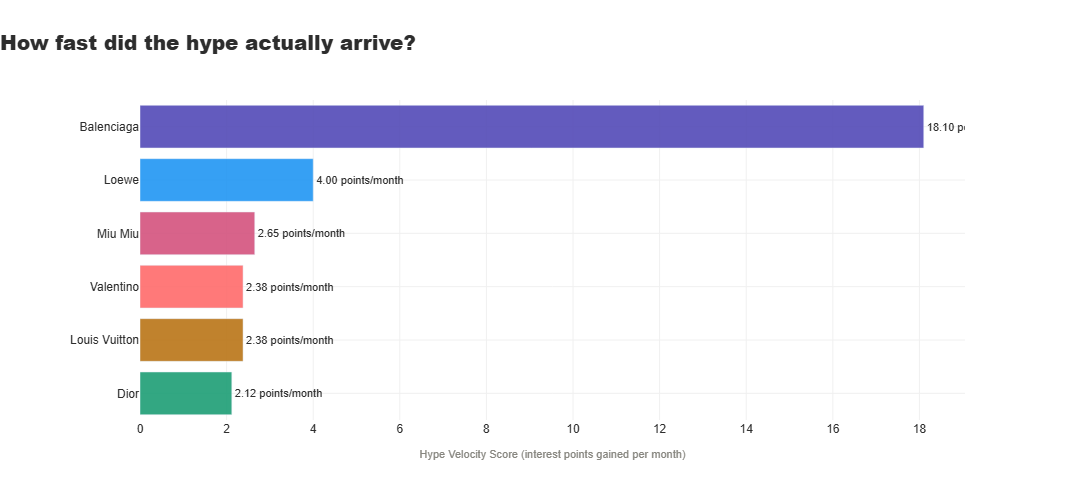


Chart 3 saved.


In [12]:
# === CHART 3: HYPE VELOCITY SCORE ===

# Define baseline period (first 6 months of 2020)
# and the month each brand started its main rise
rise_start = {
    'Miu Miu'      : '2022-01-01',
    'Balenciaga'   : '2022-06-01',
    'Louis Vuitton': '2021-06-01',
    'Dior'         : '2021-01-01',
    'Valentino'    : '2021-06-01',
    'Loewe'        : '2021-06-01'
}

velocity_data = []

for brand in brand_list:
    brand_df = df_all[df_all['Brand'] == brand].copy()
    
    # Baseline — average of first 6 months
    baseline = brand_df[
        brand_df['Month'] < '2020-07-01']['Interest'].mean()
    
    # Peak
    peak_row = brand_df.loc[brand_df['Interest'].idxmax()]
    peak_score = peak_row['Interest']
    peak_date = peak_row['Month']
    
    # Rise start
    rise_date = pd.to_datetime(rise_start[brand])
    
    # Months to peak from rise start
    months_to_peak = (
        (peak_date.year - rise_date.year) * 12 + 
        (peak_date.month - rise_date.month)
    )
    months_to_peak = max(months_to_peak, 1)
    
    # Velocity score
    velocity = (peak_score - baseline) / months_to_peak
    
    velocity_data.append({
        'Brand'          : brand,
        'Baseline'       : round(baseline, 1),
        'Peak Score'     : peak_score,
        'Months to Peak' : months_to_peak,
        'Velocity Score' : round(velocity, 2)
    })

velocity_df = pd.DataFrame(velocity_data).sort_values(
    'Velocity Score', ascending=True)

print(velocity_df.to_string(index=False))

fig = go.Figure()

fig.add_trace(go.Bar(
    x=velocity_df['Velocity Score'],
    y=velocity_df['Brand'],
    orientation='h',
    marker=dict(
        color=[brand_colors[b] for b in velocity_df['Brand']],
        opacity=0.9
    ),
    text=[f"{v:.2f} points/month" for v in velocity_df['Velocity Score']],
    textposition='outside',
    textfont=dict(size=11, family='Arial'),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Velocity Score: %{x:.2f}<br>"
        "Points gained per month<extra></extra>"
    )
))

fig.update_layout(
    title=dict(
        text='How fast did the hype actually arrive?',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Hype Velocity Score (interest points gained per month)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0'
    ),
    yaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=12, family='Arial')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=480,
    margin=dict(l=140, r=120, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart3_hype_velocity.html')
fig.write_image('charts/chart3_hype_velocity.png',
                width=1200, height=480, scale=2)
fig.show()
print("\nChart 3 saved.")

Balenciaga scored 18.10 points per month. The controversy 
erupted on November 16 2022, a holiday campaign featuring 
children with BDSM-inspired accessories and within five 
months the brand had hit its all time search peak. That is 
what 300 million TikTok views of #burnbalenciaga does to 
a Google Trends score. The fastest hype in this dataset was 
not built on a collection, a campaign, or a creative director's 
vision. It was built on outrage. The velocity was real. 
The foundation was not.

Loewe scored 4.00 over 25 months, second highest velocity 
but built entirely differently. Rihanna's Super Bowl. 
Beyoncé's Renaissance tour. Zendaya's tennis ball heels. 
Jonathan Anderson didn't manufacture cultural moments, he 
kept showing up to them until the world had no choice but 
to notice. That is a completely different relationship with 
velocity. Balenciaga arrived in five months and crashed. 
Loewe compounded for two years and kept climbing.

Miu Miu started from a baseline of 23.2, the highest floor 
in this dataset and still climbed to 100. Every other brand 
began from near zero. That floor exists because Miuccia Prada 
spent years building a brand so culturally specific that even 
in its quietest moments it was more searched than most brands 
at their loudest. You cannot manufacture a floor like that. 
You have to earn it collection by collection until it becomes 
the only number that matters.

Dior took 47 months and scored 2.12. The fashion industry 
has a word for brands that don't need velocity to stay 
relevant. They call them institutions. The data agrees.

## Act 3 : The Hype Efficiency Score

Reaching peak interest is the easy part. Every brand in this 
dataset hit 100 at some point. The harder question, the one 
the industry rarely asks out loud is what happens the month 
after. And the month after that. Does the hype compound into 
something structural, or does it evaporate the moment the 
next cultural moment arrives?

The Hype Efficiency Score measures exactly this. For each brand, 
it calculates how much of their peak interest they held onto 
in the twelve months that followed. A score of 100% means the 
brand sustained its peak entirely. A score of 30% means three 
quarters of the moment was gone within a year. This is where 
velocity becomes irrelevant and substance takes over.

Formula: Average interest in the 12 months post-peak divided 
by peak score, multiplied by 100. The brands that built 
something real will show up here. The ones that relied on 
a single moment will not.

     Brand  Peak Score Peak Date  Avg Post Peak  Months Available  Efficiency Score
Balenciaga         100  Nov 2022           36.6                12              36.6
     Loewe         100  Jul 2023           72.5                12              72.5
   Miu Miu         100  Jun 2024           90.5                 6              90.5


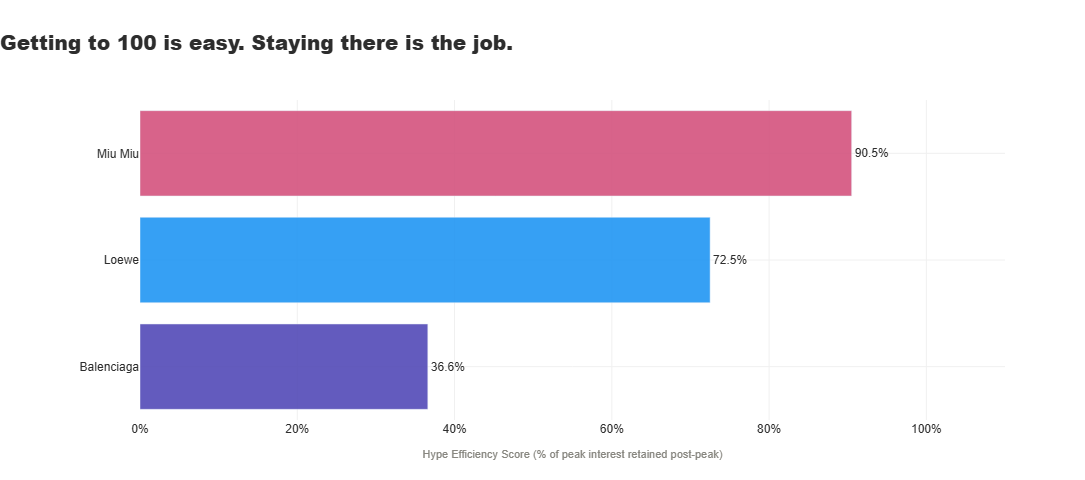


Chart 4 saved.


In [11]:
# === CHART 4: HYPE EFFICIENCY SCORE ===

efficiency_data = []

for brand in brand_list:
    brand_df = df_all[df_all['Brand'] == brand].copy()
    brand_df = brand_df.sort_values('Month').reset_index(drop=True)
    
    # Peak
    peak_idx = brand_df['Interest'].idxmax()
    peak_score = brand_df.loc[peak_idx, 'Interest']
    peak_date = brand_df.loc[peak_idx, 'Month']
    
    # 12 months post peak
    post_peak = brand_df[brand_df['Month'] > peak_date].head(12)
    
    if len(post_peak) == 0:
        efficiency = 0
    else:
        avg_post_peak = post_peak['Interest'].mean()
        efficiency = round((avg_post_peak / peak_score) * 100, 1)
    
    efficiency_data.append({
        'Brand'           : brand,
        'Peak Score'      : peak_score,
        'Peak Date'       : peak_date.strftime('%b %Y'),
        'Avg Post Peak'   : round(post_peak['Interest'].mean(), 1) if len(post_peak) > 0 else 0,
        'Months Available': len(post_peak),
        'Efficiency Score': efficiency
    })

efficiency_df = pd.DataFrame(efficiency_data)
efficiency_df = efficiency_df[efficiency_df['Months Available'] > 0]
efficiency_df = efficiency_df.sort_values('Efficiency Score', ascending=True)

print(efficiency_df.to_string(index=False))

fig = go.Figure()

fig.add_trace(go.Bar(
    x=efficiency_df['Efficiency Score'],
    y=efficiency_df['Brand'],
    orientation='h',
    marker=dict(
        color=[brand_colors[b] for b in efficiency_df['Brand']],
        opacity=0.9
    ),
    text=[f"{v:.1f}%" for v in efficiency_df['Efficiency Score']],
    textposition='outside',
    textfont=dict(size=12, family='Arial'),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Efficiency Score: %{x:.1f}%<br>"
        "Interest retained after peak<extra></extra>"
    )
))

fig.update_layout(
    title=dict(
        text='Getting to 100 is easy. Staying there is the job.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Hype Efficiency Score (% of peak interest retained post-peak)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        ticksuffix='%',
        range=[0, 110]
    ),
    yaxis=dict(
        gridcolor='#f0f0f0',
        tickfont=dict(size=12, family='Arial')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=480,
    margin=dict(l=140, r=80, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    hoverlabel=dict(
        bgcolor='grey',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart4_hype_efficiency.html')
fig.write_image('charts/chart4_hype_efficiency.png',
                width=1200, height=480, scale=2)
fig.show()
print("\nChart 4 saved.")

Three brands peaked at 100. In the months that followed, 
they became three completely different case studies.

Miu Miu retained 90.5% of its peak interest across the six 
months after June 2024. That is not a brand riding a moment  
that is a brand that became the baseline. When 93.2% sales 
growth and two consecutive Lyst Brand of the Year titles are 
your context, 90.5% efficiency isn't surprising. It is 
the logical conclusion of a brand that never needed a spike 
because it was already everywhere.

Loewe retained 72.5% across a full twelve months after its 
July 2023 peak. Rihanna's Super Bowl. Beyoncé's Renaissance 
tour. Zendaya's tennis ball heels. Jonathan Anderson dressed 
cultural moments so consistently that when the peak arrived 
the audience was already there waiting. 72.5% efficiency 
over twelve months is what a decade of deliberate brand 
building looks like when it finally compounds.

Balenciaga retained 36.6%. The controversy hit in November 
2022, sent search interest vertical, and then left. Two 
flagship stores vandalized. Dua Lipa refused to wear the 
clothes on tour. Bella Hadid deleted the campaign posts. 
The brand fell from number one to number eighteen on the 
Lyst Index in two quarters. 36.6% is what's left when the 
outrage moves on and takes the audience with it. Louis 
Vuitton, Dior and Valentino peaked in December 2024 — 
the last month of this dataset, so their efficiency 
scores remain to be written. The data just hasn't caught 
up yet.

## Act 4 : The Hype Matrix

Velocity and efficiency are not the same thing. A brand can 
arrive fast and fade faster. It can build slowly and hold 
everything it earned. The relationship between the two is 
where the real story lives and it looks different for 
every brand in this dataset.

The Hype Matrix plots all six brands on two axes: how fast 
they built their hype on the horizontal, and how much of 
it they kept on the vertical. Four quadrants emerge. Top 
left is the slow burn that lasted, the most valuable 
position in luxury. Top right is the explosive arrival 
that somehow held. Bottom left barely registered and 
didn't hold much either. Bottom right is the one nobody 
wants to be fast arrival, fast exit.

One brand sits alone in that bottom right quadrant. 
The data has been building to this moment since Chart 1.

     Brand  Velocity Score  Efficiency Score
Balenciaga           18.10              36.6
     Loewe            4.00              72.5
   Miu Miu            2.65              90.5


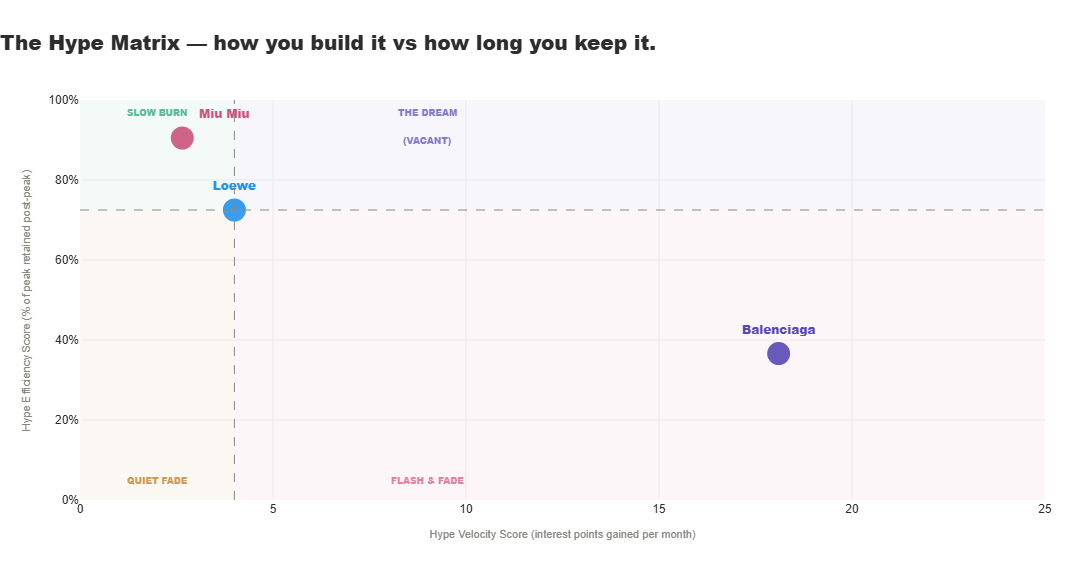

Chart 5 saved.


In [17]:
# === CHART 5: THE HYPE MATRIX ===

# Merge velocity and efficiency
velocity_df_indexed = velocity_df.set_index('Brand')
efficiency_df_indexed = efficiency_df.set_index('Brand')

matrix_brands = list(efficiency_df_indexed.index)

matrix_data = []
for brand in matrix_brands:
    matrix_data.append({
        'Brand'            : brand,
        'Velocity Score'   : velocity_df_indexed.loc[brand, 'Velocity Score'],
        'Efficiency Score' : efficiency_df_indexed.loc[brand, 'Efficiency Score'],
    })

matrix_df = pd.DataFrame(matrix_data)
print(matrix_df.to_string(index=False))

# Midpoints for quadrant lines
mid_velocity   = matrix_df['Velocity Score'].median()
mid_efficiency = matrix_df['Efficiency Score'].median()

fig = go.Figure()

# Quadrant shading
fig.add_shape(type='rect',
    x0=0, x1=mid_velocity,
    y0=mid_efficiency, y1=100,
    fillcolor='rgba(29,158,117,0.05)',
    line=dict(width=0))

fig.add_shape(type='rect',
    x0=mid_velocity, x1=25,
    y0=mid_efficiency, y1=100,
    fillcolor='rgba(83,74,183,0.05)',
    line=dict(width=0))

fig.add_shape(type='rect',
    x0=0, x1=mid_velocity,
    y0=0, y1=mid_efficiency,
    fillcolor='rgba(186,117,23,0.05)',
    line=dict(width=0))

fig.add_shape(type='rect',
    x0=mid_velocity, x1=25,
    y0=0, y1=mid_efficiency,
    fillcolor='rgba(212,83,126,0.05)',
    line=dict(width=0))

# Quadrant labels
quadrant_labels = [
    {'x': mid_velocity/2,    'y': 97, 
     'text': 'SLOW BURN',    'color': '#1D9E75'},
    {'x': mid_velocity + 5,  'y': 97, 
     'text': 'THE DREAM',    'color': '#534AB7'},
    {'x': mid_velocity + 5,  'y': 90, 
     'text': '(VACANT)',     'color': '#534AB7'},
    {'x': mid_velocity/2,    'y': 5,  
     'text': 'QUIET FADE',   'color': '#BA7517'},
    {'x': mid_velocity + 5,  'y': 5,  
     'text': 'FLASH & FADE', 'color': '#D4537E'},
]

for ql in quadrant_labels:
    fig.add_annotation(
        x=ql['x'], y=ql['y'],
        text=ql['text'],
        showarrow=False,
        font=dict(size=9, color=ql['color'],
                  family='Arial Black'),
        opacity=0.7
    )

# Midpoint lines
fig.add_shape(type='line',
    x0=mid_velocity, x1=mid_velocity,
    y0=0, y1=100,
    line=dict(color='#888780', width=1, dash='dash'))

fig.add_shape(type='line',
    x0=0, x1=25,
    y0=mid_efficiency, y1=mid_efficiency,
    line=dict(color='#888780', width=1, dash='dash'))

# Brand bubbles
for _, row in matrix_df.iterrows():
    brand = row['Brand']
    color = brand_colors[brand]

    fig.add_trace(go.Scatter(
        x=[row['Velocity Score']],
        y=[row['Efficiency Score']],
        mode='markers+text',
        name=brand,
        text=[brand if brand != 'Miu Miu' else 'Miu Miu  '],
        textposition='top right' if brand == 'Miu Miu' else 'top center',
        textfont=dict(size=12, color=color,
                      family='Arial Black'),
        marker=dict(
            size=25,
            color=color,
            opacity=0.9,
            line=dict(color='white', width=2)
        ),
        hovertemplate=(
            f"<b>{brand}</b><br>"
            f"Velocity: {row['Velocity Score']:.2f} pts/month<br>"
            f"Efficiency: {row['Efficiency Score']:.1f}%"
            "<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(
        text='The Hype Matrix — how you build it vs how long you keep it.',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title=dict(
            text='Hype Velocity Score (interest points gained per month)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        range=[0, 25]
    ),
    yaxis=dict(
        title=dict(
            text='Hype Efficiency Score (% of peak retained post-peak)',
            font=dict(size=11, color='#888780')
        ),
        gridcolor='#f0f0f0',
        ticksuffix='%',
        range=[0, 100]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=580,
    margin=dict(l=80, r=40, t=100, b=80),
    font=dict(family='Arial', color='#2d2d2d'),
    showlegend=False,
    hoverlabel=dict(
        bgcolor='white',
        bordercolor='#f0f0f0',
        font=dict(size=12, family='Arial'),
        namelength=-1
    )
)

fig.write_html('charts/chart5_hype_matrix.html')
fig.write_image('charts/chart5_hype_matrix.png',
                width=1200, height=580, scale=2)
fig.show()
print("Chart 5 saved.")

The Dream quadrant is vacant. No brand in this dataset built 
fast AND held it. Not one. The fashion industry spends billions 
trying to manufacture cultural moments and the data says the 
fastest ones are always the least durable. That empty top right 
corner is the most expensive real estate in luxury marketing 
and nobody is living there.

Miu Miu sits alone in Slow Burn, lowest velocity in the 
dataset, highest efficiency. 93.2% sales growth. Two 
consecutive Lyst Brand of the Year titles. A baseline that 
never dropped below 20 even before its rise began. Miuccia 
Prada did not chase the moment. She built the conditions 
for it and then waited. The pink dot in the top left is 
what patience looks like when it finally compounds.

Loewe sits exactly on the dividing line, fast enough to 
be noticed, slow enough to be durable. Jonathan Anderson 
threaded the needle so precisely that the data literally 
cannot decide which quadrant he belongs in. That is not 
an accident. That is ten years of deliberate brand building 
finding its mathematical expression.

Balenciaga is alone in Flash & Fade. The fastest velocity 
in the dataset. The lowest efficiency of the three. Arrived 
in five months, kept barely a third of it. The controversy 
generated 300 million TikTok views and a Google Trends score 
of 100. It also generated #burnbalenciaga. Those are not 
the same thing and the matrix knows the difference.

## So, What Does The Data Actually Know About Hype?

It knows that the fastest hype is almost never the most 
durable. The Dream quadrant, high velocity, high efficiency, is completely empty. Not one brand in five years of data 
managed to explode onto the cultural scene and hold it. The 
fashion industry's obsession with the viral moment, the 
overnight sensation, the campaign that breaks the internet, the data suggests this is precisely the wrong thing to 
optimise for.

It knows that Miu Miu is not having a moment. It is having 
a decade. The micro mini skirt was not the beginning of 
the story, it was the moment the rest of the world caught 
up to a brand that had been building something real since 
Miuccia Prada decided that being a Miu Miu girl was a state 
of mind rather than a demographic. 90.5% efficiency. 93.2% 
sales growth. The hottest brand in the world two years 
running. The pink line on that chart never stops climbing 
because the brand never stopped earning it.

It knows that controversy generates search interest and 
destroys brand equity simultaneously. Balenciaga hit 100 
on Google Trends and number eighteen on the Lyst Index in 
the same quarter. 300 million TikTok views of 
#burnbalenciaga will do that. The velocity was real. 
The foundation was not. 36.6% efficiency is what remains 
when the outrage moves on and takes the audience with it.

And it knows that the most interesting brand story in this 
dataset is the one that built slowest and held longest. 
Loewe went from invisible to inevitable in 25 months. 
Rihanna's Super Bowl. Beyoncé's Renaissance tour. 
Zendaya's tennis ball heels. Jonathan Anderson didn't 
manufacture cultural moments, he kept showing up to them 
until showing up became the brand identity. The data caught 
every step. Fashion moves fast. The half life of hype 
is shorter than the industry thinks. And the brands that 
last are the ones that never needed it to be long.

---

**Analyst:** Trupthi Raj
**GitHub:** [github.com/trupthiraj](https://github.com/trupthiraj)
**Tableau:** [public.tableau.com/app/profile/trupthi.raj/vizzes](https://public.tableau.com/app/profile/trupthi.raj/vizzes)